In [4]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import tensorflow as tf
from tensorflow import keras
import numpy as np
from tqdm import tqdm
import pandas as pd
from zapbench import constants
from zapbench.ts_forecasting import data_source
import grain.python as grain
from zapbench import data_utils
from zapbench.models.child775_model import Model
import matplotlib.pyplot as plt


In [5]:
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [8]:
num_timesteps_context = 4
prediction_window_length = 16 # constants.PREDICTION_WINDOW_LENGTH

In [9]:
sources = []

# Iterate over all training conditions (excludes 'taxis'), and create
# data sources.
for condition_id in constants.CONDITIONS_TRAIN:
  config = data_source.TensorStoreTimeSeriesConfig(
      input_spec=data_utils.adjust_spec_for_condition_and_split(
          condition=condition_id,
          split='train',
          spec=data_utils.get_spec('240930_traces'),
          num_timesteps_context=num_timesteps_context),
      timesteps_input=num_timesteps_context,
      timesteps_output=prediction_window_length,
  )
  sources.append(data_source.TensorStoreTimeSeries(config, prefetch=True))

# Concatenate into a single source.
source = data_source.ConcatenatedTensorStoreTimeSeries(*sources)

f'{len(source)=}'

'len(source)=4900'

In [10]:

# Dynamically infer the necessary constants from the data source for model instantiation.

num_epochs = 1
shuffle=False
batch_size = 32

NUM_NEURONS_INFERRED = source[0]['series_input'].shape[1]

NUM_TIMESTEPS_CONTEXT_INFERRED = num_timesteps_context
# Define the number of epochs to train for model.fit
epochs_to_train_for_model_fit = 120
# Setup train data loader: ensure num_epochs is 1 for consistent tf.data.Dataset generation per epoch
index_sampler = grain.IndexSampler(
    num_records=len(source),
    num_epochs=num_epochs, # This should be 1 as defined globally initially
    shard_options=grain.ShardOptions(
        shard_index=0, shard_count=1, drop_remainder=True),
    shuffle=shuffle,
    seed=101
)
data_loader = grain.DataLoader(
    data_source=source,
    sampler=index_sampler,
    operations=[
        grain.Batch(
            batch_size=batch_size, drop_remainder=True)
    ],
    worker_count=0
)
# Setup validation data loader: ensure num_epochs is 1
val_sources = []
for condition_id in constants.CONDITIONS_TRAIN: # Use training conditions for validation split
  config_val = data_source.TensorStoreTimeSeriesConfig(
      input_spec=data_utils.adjust_spec_for_condition_and_split(
          condition=condition_id,
          split='val', # Crucially, use 'val' split here
          spec=data_utils.get_spec('240930_traces'),
          num_timesteps_context=num_timesteps_context),
      timesteps_input=num_timesteps_context,
      timesteps_output=prediction_window_length,
  )
  val_sources.append(data_source.TensorStoreTimeSeries(config_val, prefetch=True))
val_source = data_source.ConcatenatedTensorStoreTimeSeries(*val_sources)
val_batch_size = batch_size # Use same batch size for validation
val_index_sampler = grain.IndexSampler(
    num_records=len(val_source),
    num_epochs=num_epochs, # This should be 1
    shard_options=grain.ShardOptions(
        shard_index=0, shard_count=1, drop_remainder=True),
    shuffle=False, # No need to shuffle validation data
    seed=101 # Consistent seed
)
val_data_loader = grain.DataLoader(
    data_source=val_source,
    sampler=val_index_sampler,
    operations=[
        grain.Batch(
            batch_size=val_batch_size, drop_remainder=True)
    ],
    worker_count=0
)
print(f'\nValidation data loader created with {len(val_source)} records and batch size {val_batch_size}.')



Validation data loader created with 597 records and batch size 32.


0.8179069375972308

In [11]:
# mirrored_strategy = tf.distribute.MirroredStrategy()
# with mirrored_strategy.scope():
# Instantiate the model by passing the required constants.
model = Model(
    num_timesteps_context=NUM_TIMESTEPS_CONTEXT_INFERRED,
    num_neurons=NUM_NEURONS_INFERRED,
    prediction_window_length=prediction_window_length
)
# Perform a dummy forward pass using the actual batch_size to build the model
# and ensure all layer shapes are determined, including those within FeatureExtractor.
dummy_input_for_build = tf.zeros((batch_size, NUM_TIMESTEPS_CONTEXT_INFERRED, NUM_NEURONS_INFERRED), dtype=tf.float32)
_ = model(dummy_input_for_build) # Call the model once to build its layers
print("\nShared-Weight MLP Model Summary (with encapsulated and consolidated FeatureExtractor and Residual Blocks):")
model.summary()
total_params = model.count_params()
# The input dimension to the MLP is now determined by the FeatureExtractor's output
# It's (conv1d_filters + 8 stats + (C-1) deltas + GLOBAL_STATE_DIM + EMBEDDING_DIM)
total_mlp_input_dim = (model.feature_extractor.conv1d_context_processor.filters +
                      8 + # number of static features (mean, std, min, max, last, first, median, range)
                      (model.NUM_TIMESTEPS_CONTEXT - 1) + # number of delta features
                      model.feature_extractor.GLOBAL_STATE_DIM +
                      model.feature_extractor.EMBEDDING_DIM)
print(f"\nTotal combined model parameters: {total_params:,}.")
print(f"This compact model shares its weights across {model.NUM_NEURONS} neurons to predict their future activity.")
print(f"This design is critical for managing the vast number of outputs ({model.NUM_NEURONS} neurons * {model.PREDICTION_WINDOW_LENGTH} steps), providing both local and global context, neuron identity, and now rate of change, with a total input dimension to the MLP of {total_mlp_input_dim}.")
# Now using the encapsulated 'fit' method with validation data.
model.fit(train_data_loader=data_loader, val_data_loader=val_data_loader, epochs=epochs_to_train_for_model_fit)

I0000 00:00:1761240134.064211   92687 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46718 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:04:00.0, compute capability: 8.6



Shared-Weight MLP Model Summary (with encapsulated and consolidated FeatureExtractor and Residual Blocks):


Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_extractor_layer         │ ?                      │    13,770,848 │
│ (FeatureExtractor)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ initial_bn (BatchNormalization) │ (2295072, 267)         │         1,068 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ initial_projection_dense        │ (2295072, 256)         │        68,608 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block1 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block2 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block3 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block4 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_output_dense (Dense)      │ (2295072, 16)          │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,111,900 (53.83 MB)

...

2025-10-23 14:34:39.946252: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14345921368855247834
2025-10-23 14:34:39.946327: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14005905728425462794


153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - loss: 0.0272

2025-10-23 14:36:04.804027: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14005905728425462794


153/153 ━━━━━━━━━━━━━━━━━━━━ 89s 579ms/step - loss: 0.0267 - val_loss: 0.0277
Epoch 48: early stopping
Restoring model weights from the end of the best epoch: 28.
Training completed after 120 epochs (or early stopping).


2025-10-23 14:36:09.235260: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14345921368855247834
2025-10-23 14:36:09.235334: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14005905728425462794


In [14]:
model.save("/groups/saalfeld/saalfeldlab/zapbench-processed/ai_scientist_paper/trained_child775_context4_predict16.keras", zipped=True, overwrite=False)

In [301]:
model.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_extractor_layer         │ ?                      │    13,770,848 │
│ (FeatureExtractor)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ initial_bn (BatchNormalization) │ (2295072, 267)         │         1,068 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ initial_projection_dense        │ (2295072, 256)         │        68,608 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block1 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block2 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block3 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block4 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_output_dense (Dense)      │ (2295072, 16)          │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,330,538 (161.48 MB)

 Trainable params: 14,109,318 (53.82 MB)

 Non-trainable params: 2,582 (10.09 KB)

 Optimizer params: 28,218,638 (107.65 MB)

In [ ]:
# model.save("child775.keras", overwrite=False, zipped=True)

(1.0, 120.0)

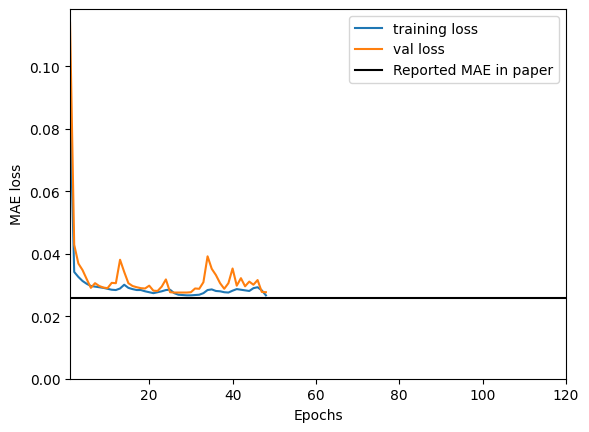

In [303]:
loss = []
val_loss = []
for row in """epoch,loss,val_loss
1,0.0869,0.1140
2,0.0342,0.0429
3,0.0326,0.0369
4,0.0313,0.0348
5,0.0304,0.0319
6,0.0297,0.0291
7,0.0295,0.0306
8,0.0293,0.0297
9,0.0291,0.0292
10,0.0288,0.0290
11,0.0285,0.0307
12,0.0284,0.0306
13,0.0289,0.0381
14,0.0301,0.0342
15,0.0291,0.0306
16,0.0287,0.0297
17,0.0284,0.0293
18,0.0284,0.0290
19,0.0280,0.0289
20,0.0277,0.0298
21,0.0274,0.0282
22,0.0277,0.0281
23,0.0280,0.0295
24,0.0284,0.0318
25,0.0285,0.0277
26,0.0274,0.0276
27,0.0269,0.0276
28,0.0268,0.0276
29,0.0267,0.0276
30,0.0267,0.0277
31,0.0268,0.0289
32,0.0269,0.0288
33,0.0274,0.0309
34,0.0284,0.0392
35,0.0286,0.0352
36,0.0281,0.0332
37,0.0280,0.0306
38,0.0277,0.0288
39,0.0276,0.0306
40,0.0282,0.0353
41,0.0287,0.0298
42,0.0285,0.0322
43,0.0283,0.0296
44,0.0281,0.0311
45,0.0290,0.0301
46,0.0293,0.0316
47,0.0283,0.0278
48,0.0267,0.0277""".strip().split()[1:]:
  f = row.split(",")
  loss.append(float(f[1]))
  val_loss.append(float(f[2]))
plt.plot(np.arange(1, 49), loss, label="training loss")
plt.plot(np.arange(1, 49), val_loss, label="val loss")
plt.xlabel("Epochs")
plt.axhline(0.026, color="k", label="Reported MAE in paper")
plt.legend()
plt.ylabel("MAE loss")
plt.ylim(0, None)
plt.xlim(1, 120)
# plt.grid(True)

In [149]:
x = np.array([source[i]['series_input'] for i in range(len(source))])
y = np.array([source[i]['series_output'] for i in range(len(source))])

In [216]:
data_ix =  np.random.randint(len(source))

ypred = model.predict_non_batched(x[data_ix])

# ix = np.random.randint(0, 71721)


data_ix=2011;ix=6205


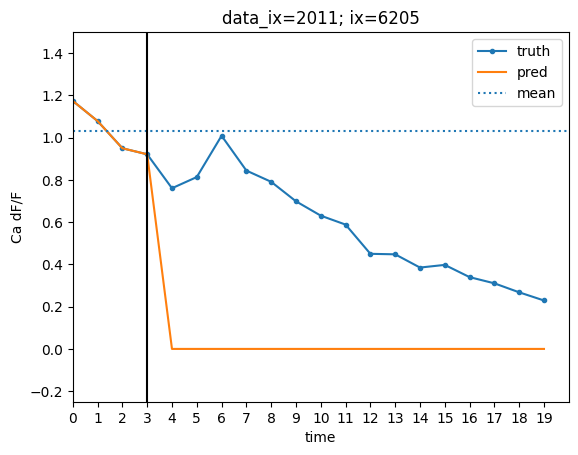

In [221]:


ix = int(np.random.choice(np.argsort(y[data_ix].mean(axis=0) - x[data_ix].mean(axis=0))[:50]))


print(f"{data_ix=};{ix=}")
plt.plot(np.concatenate([x[data_ix, :, ix], y[data_ix, :, ix]], axis=0), label="truth", marker=".")
plt.plot(np.concatenate([x[data_ix, :, ix], ypred[:, ix]], axis=0), label="pred")
plt.axhline(x[data_ix, :, ix].mean(), label="mean", ls="dotted")
plt.plot()
plt.xlim(0, 20)
plt.legend()
plt.xticks(np.arange(20))
plt.ylim(-0.25, 1.5)
plt.title(f"{data_ix=}; {ix=}")
plt.xlabel("time")
plt.ylabel("Ca dF/F")
plt.axvline(num_timesteps_context - 1, color="k")

In [ ]:
np.random.seed(0)
data_ixs =  np.random.choice(len(source), size=500, replace=False)

mae_means = []
mae_preds = []
ystds = []
for data_ix in data_ixs:
  x = source[data_ix]['series_input']
  y = source[data_ix]['series_output']
  ypred = model.predict_non_batched(x)
  mae_pred = np.abs(ypred - y).mean()
  mae_mean = np.abs(y - x.mean(axis=0)).mean()
  mae_means.append(mae_mean)
  mae_preds.append(mae_pred)


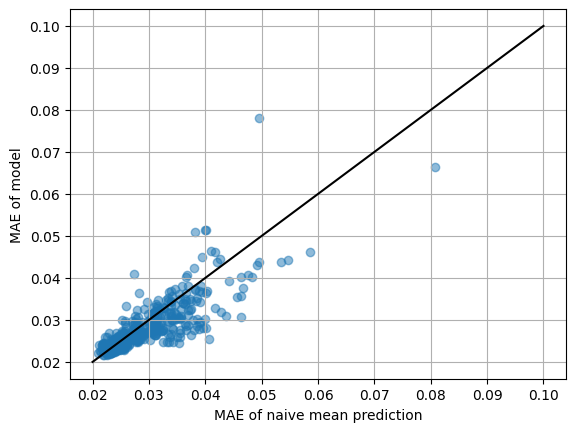

In [240]:
plt.scatter(mae_means, mae_preds, alpha=0.5)
plt.plot([0.02, 0.1], [0.02, 0.1], color="k")
plt.xlabel("MAE of naive mean prediction")
plt.ylabel("MAE of model")
plt.grid(True)
pass

In [ ]:
np.random.seed(0)
data_ixs =  np.random.choice(len(source), size=100, replace=False)


model_r2 = []
variance = []
mae_preds = []
mae_means = []
mads = []
all_ixs = []
for data_ix in data_ixs:
  x = source[data_ix]['series_input']
  y = source[data_ix]['series_output']
  ypred = model.predict_non_batched(x)
  mae_pred = np.abs(ypred - y).mean(0)
  mae_mean = np.abs(y - x.mean(axis=0)).mean(0)
  total_var = y.var(0)
  explained_var = total_var - (y - ypred).var(0)
  mad = np.abs(y - y.mean(0)).mean(0)
  ixs = np.random.choice(71721, size=1000)
  model_r2.extend((explained_var/total_var)[ixs])
  variance.extend(total_var[ixs])
  mae_preds.extend(mae_pred[ixs])
  mae_means.extend(mae_mean[ixs])
  mads.extend(mad[ixs])
  all_ixs.extend(ixs)


In [316]:
import polars as pl
df = pl.DataFrame({
  "mad": mads,
  "model": mae_preds,
  "mean": mae_means,
  "r2": model_r2,
})
res = df.group_by(pl.col("mad").qcut(10).alias("bin")).agg(
  pl.col("mad").mean(),
  pl.col("model"),
  pl.col("mean"),
  "r2"
).sort("mad")


Text(0, 0.5, 'MAE')

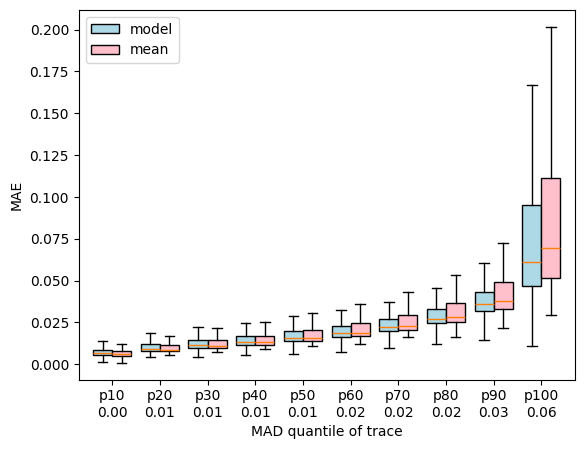

In [317]:
boxes_model = res["model"].to_list()
boxes_mean = res["mean"].to_list()
mad_pts = res["mad"].to_numpy()
p = plt.boxplot(boxes_model, positions=np.arange(1, 11)-0.2, widths=0.4, showfliers=False, patch_artist=True, label="model")
for patch in p['boxes']: patch.set_facecolor('lightblue')

p = plt.boxplot(boxes_mean, positions=np.arange(1, 11)+0.2, widths=0.4, showfliers=False, patch_artist=True, label="mean")
for patch in p['boxes']: patch.set_facecolor('pink')
plt.xticks(np.arange(1, 11), [f"p{p}\n{m:.2f}" for p, m in zip(range(10, 110, 10), res["mad"])])
plt.legend()
plt.xlabel("MAD quantile of trace")
plt.ylabel("MAE")

Text(0, 0.5, 'R2 of prediction')

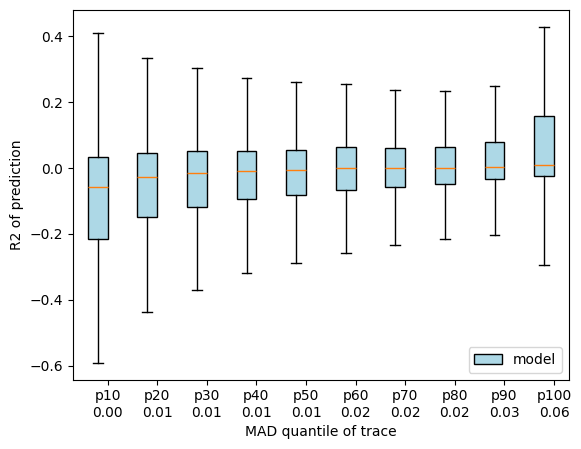

In [319]:
boxes_model = res["r2"].to_list()
mad_pts = res["mad"].to_numpy()
p = plt.boxplot(boxes_model, positions=np.arange(1, 11)-0.2, widths=0.4, showfliers=False, patch_artist=True, label="model")
for patch in p['boxes']: patch.set_facecolor('lightblue')

plt.xticks(np.arange(1, 11), [f"p{p}\n{m:.2f}" for p, m in zip(range(10, 110, 10), res["mad"])])
plt.legend()
plt.xlabel("MAD quantile of trace")
plt.ylabel("R2 of prediction")

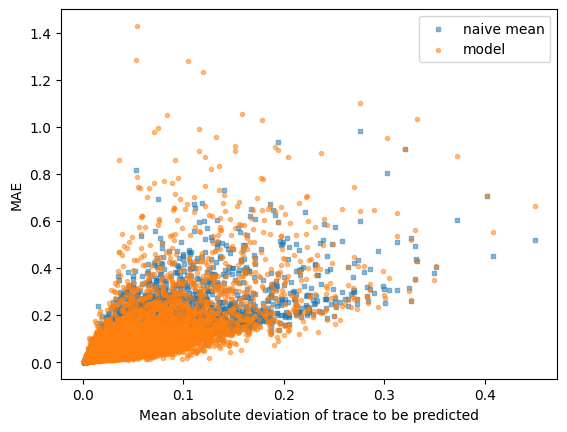

In [268]:
plt.scatter(mads, mae_means, marker="s", s=5, alpha=0.5, label="naive mean")
plt.scatter(mads, mae_preds, marker=".", alpha=0.5, label="model")

plt.xlabel("Mean absolute deviation of trace to be predicted")
plt.ylabel("MAE")
plt.legend()


(-1.0, 1.0)

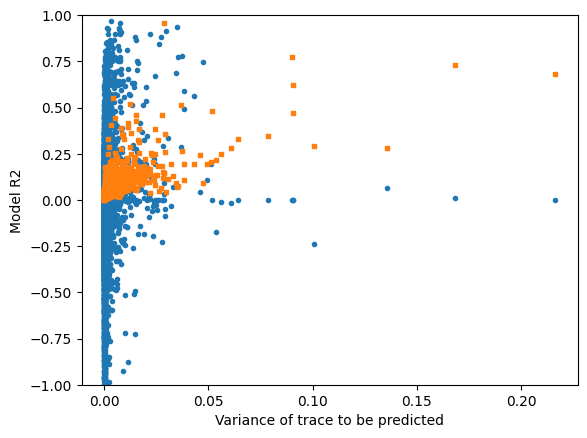

In [258]:
plt.scatter(variance, model_r2, marker=".")
plt.scatter(variance, mae_preds, marker="s", s=10)

plt.xlabel("Variance of trace to be predicted")
plt.ylabel("Model R2")
plt.ylim(-1, 1.0)